In [13]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# PCA
from sklearn.decomposition import PCA

# scaling and train/test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# keras framework
import keras
from keras.models import Sequential
from keras.layers import Dense, Input

# model evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score

In [2]:
# load dataset
df = pd.read_csv('diabetes_pima.csv')

display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# df inspection
display(df.shape) # 789x9

display(df.describe())

df.isna().sum() # 0 missing values

(768, 9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# EDA and Plotting
- Pairplot
- Histograms (age, blood glucose, insulin)

/home/james/miniconda3/envs/analysis/lib/python3.9/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/james/miniconda3/envs/analysis/lib/python3.9/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/james/miniconda3/envs/analysis/lib/python3.9/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/james/miniconda3/envs/analysis/lib/python3.9/site-packages/seaborn/axisgrid.py:1615: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/home/james/miniconda3/envs/analysis/lib/python3.9/site-packages/seaborn/axisgrid.py:1615: UserWarning: The palette list has more values 

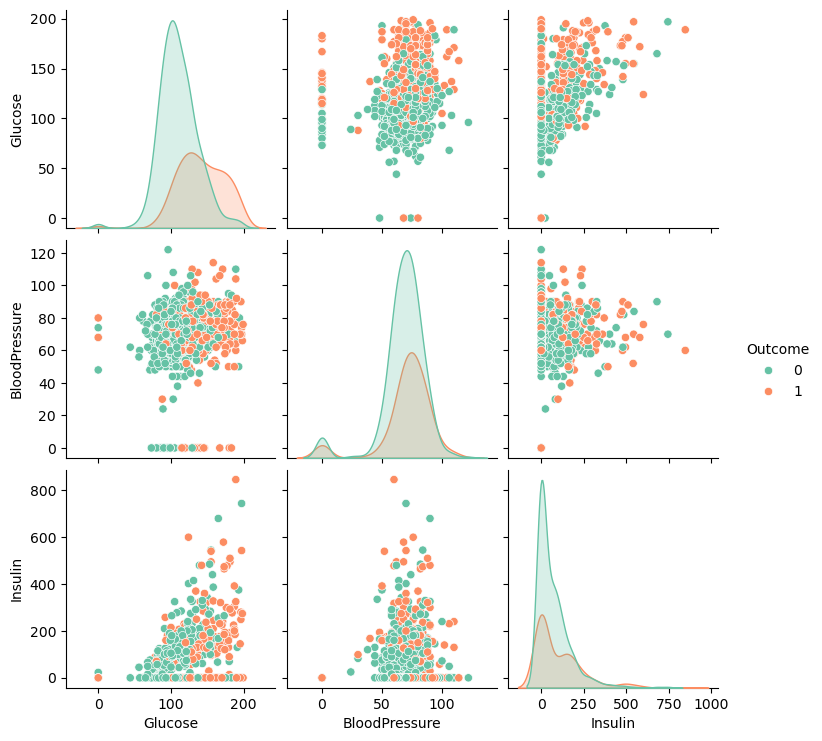

In [4]:
col_pal = sns.color_palette('Set2')

# pairplots
pair_cols = [
    'Glucose', 
    'BloodPressure', 
    'Insulin',
    'Outcome'
]

sns.pairplot(
    data=df[pair_cols], #df_scaled[pair_cols],
    diag_kind='kde',
    hue='Outcome',
    palette=col_pal
)

/tmp/ipykernel_139552/883566278.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(


<Axes: xlabel='Age', ylabel='Count'>

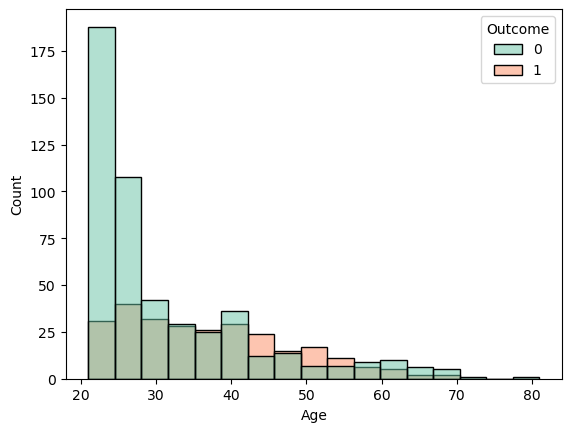

In [5]:
# histogram of ages
sns.histplot(
    data=df,
    x='Age',
    hue='Outcome',
    palette=col_pal
)

/tmp/ipykernel_139552/3473612343.py:1: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


<Axes: xlabel='Outcome', ylabel='Age'>

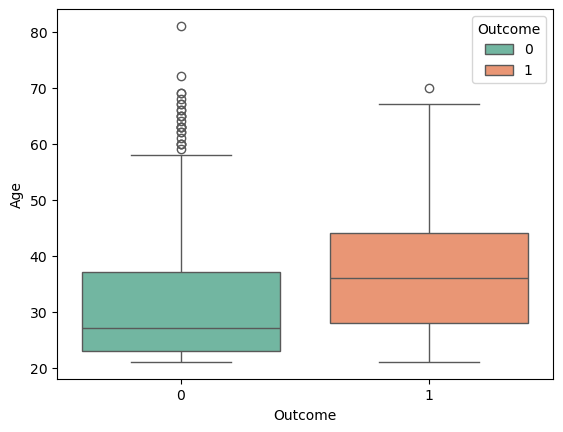

In [6]:
sns.boxplot(
    data=df,
    x='Outcome',
    y='Age',
    hue='Outcome',
    palette=col_pal
)

/tmp/ipykernel_139552/2135612078.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.displot(


Text(0.5, 1.0, 'Distribution of BMI across Outcomes')

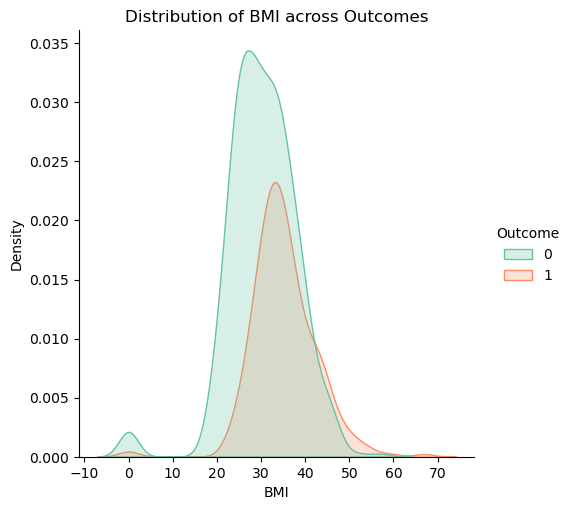

In [7]:
# histogram of blood glucose
sns.displot(
    kind='kde',
    data=df,
    x='BMI',
    hue='Outcome',
    fill=True,
    palette=col_pal)

plt.title('Distribution of BMI across Outcomes')

/tmp/ipykernel_139552/1572979594.py:2: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.displot(


Text(0.5, 1.0, 'Distribution of Blood Glucose across Outcomes')

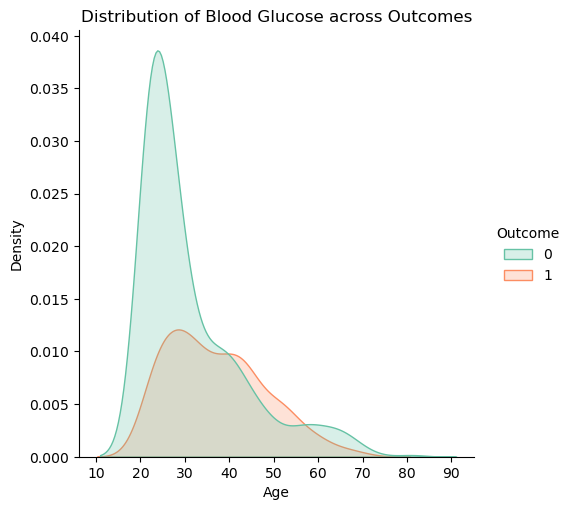

In [8]:
# histogram of blood glucose
sns.displot(
    kind='kde',
    data=df,
    x='Age',
    hue='Outcome',
    fill=True,
    palette=col_pal)

plt.title('Distribution of Blood Glucose across Outcomes')

In [9]:
# correlation
corr_cols = ['Glucose', 
             'BloodPressure', 
             'SkinThickness', 
             'Insulin',
             'BMI', 
             'DiabetesPedigreeFunction', 
             'Age', 
             'Outcome'
            ]

corr_mat = df[corr_cols].corr()

Text(0.5, 1.0, 'Correlation of Factors in Diabetes')

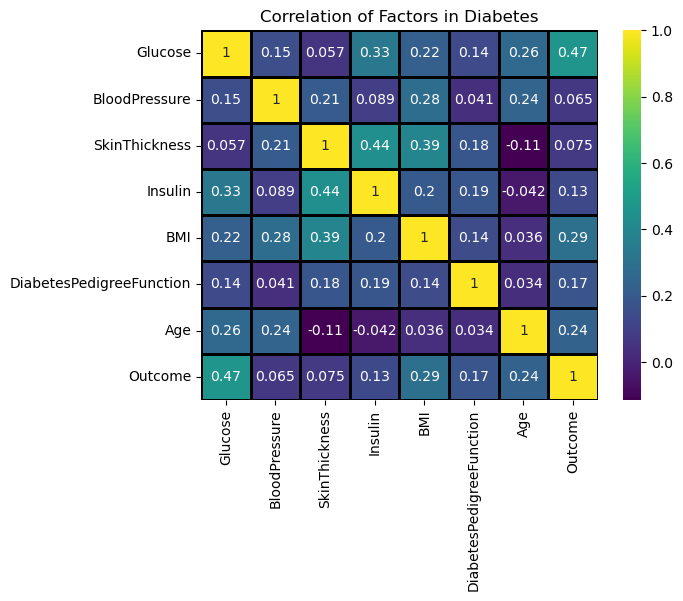

In [10]:
# correlation heatmap

sns.heatmap(
    data=corr_mat,
    cmap='viridis',
    annot=True,
    linecolor='k',
    linewidths=1
)

plt.title('Correlation of Factors in Diabetes')

#bottom, top = fig.get_ylim()

#fig.set_ylim(bottom + 0.5, top - 0.5) # adjustment to prevent excess box height

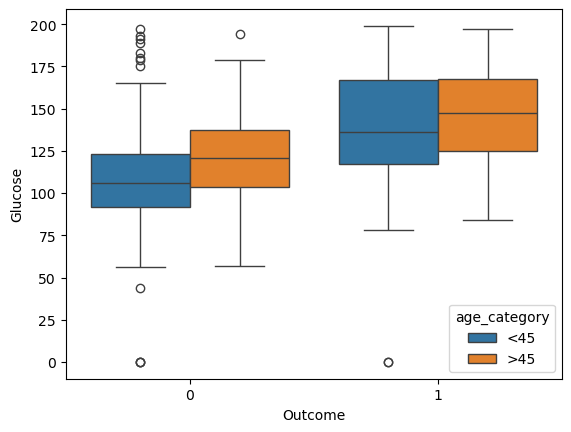

In [11]:
# sex vs bmi boxplot
age_bins = [0, 45, np.inf]
age_categories = ['<45', '>45']

df['age_category'] = pd.cut(df['Age'], 
                            age_bins, 
                            labels=age_categories)

sns.boxplot(
    data=df,
    x='Outcome',
    y='Glucose',
    hue='age_category')

df = df.drop(columns='age_category')

## PCA

In [14]:
features = df.drop(columns='Outcome') # separate features from label

x = StandardScaler().fit_transform(features) # z-scaling of feature values

pca = PCA(n_components=8) # 8 PCs

principalComponents = pca.fit_transform(x)

principalComponents.shape # 768x8

(768, 8)

In [15]:
# create z-scored df from scaled features and outcome
df_scaled = pd.concat([pd.DataFrame(x), df[['Outcome']]], axis = 1)

df_scaled.columns = df.columns # assign og column names to scaled df

df_scaled.head

<bound method NDFrame.head of      Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.639947  0.848324       0.149641       0.907270 -0.692891  0.204013   
1      -0.844885 -1.123396      -0.160546       0.530902 -0.692891 -0.684422   
2       1.233880  1.943724      -0.263941      -1.288212 -0.692891 -1.103255   
3      -0.844885 -0.998208      -0.160546       0.154533  0.123302 -0.494043   
4      -1.141852  0.504055      -1.504687       0.907270  0.765836  1.409746   
..           ...       ...            ...            ...       ...       ...   
763     1.827813 -0.622642       0.356432       1.722735  0.870031  0.115169   
764    -0.547919  0.034598       0.046245       0.405445 -0.692891  0.610154   
765     0.342981  0.003301       0.149641       0.154533  0.279594 -0.735190   
766    -0.844885  0.159787      -0.470732      -1.288212 -0.692891 -0.240205   
767    -0.844885 -0.873019       0.046245       0.656358 -0.692891 -0.202129   

     Diab

In [16]:
# PC1 to 8
pc_cols = [] # loop for PC1 to PC8
for i in range(1,9):
    pc_cols.append(f"PC{i}")

principalDf = pd.DataFrame(data = principalComponents, columns = pc_cols) # PC df

finalDf = pd.concat([principalDf, df[['Outcome']]], axis = 1) # concatenate labels (outcome) to PC df

finalDf.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Outcome
0,1.068503,1.234895,-0.095930,0.496990,0.109985,0.357183,0.858821,0.974304,1
1,-1.121683,-0.733852,0.712938,0.285056,0.389507,-0.406329,0.757034,0.354215,0
2,-0.396477,1.595876,-1.760678,-0.070395,-0.906474,-0.040018,-1.152990,1.068528,1
3,-1.115781,-1.271241,0.663729,-0.579123,0.356060,-0.412520,-0.029247,-0.130648,0
4,2.359334,-2.184819,-2.963107,4.033099,-0.592684,1.078341,0.549358,-0.319352,1


/tmp/ipykernel_139552/3595922389.py:3: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(


Text(0.5, 1.0, 'PC1 vs PC2')

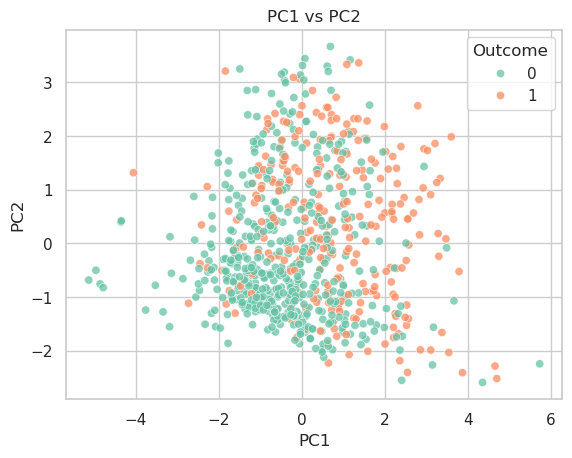

In [17]:
sns.set_theme(style='whitegrid')

sns.scatterplot(
    data=finalDf,
    x='PC1',
    y='PC2',
    hue='Outcome',
    palette=col_pal,
    alpha=0.75)

plt.title('PC1 vs PC2')

In [18]:
# variance per principal component - scree plot
pc_variances = pd.DataFrame(pca.explained_variance_ratio_)
pc_variances['variance'] = pc_variances[0]*100 
pc_variances['PrComp'] = range(1,9)

pc_variances.head()

,0,variance,PrComp
0,0.261797,26.179749,1
1,0.216401,21.640127,2
2,0.128704,12.870373,3
3,0.109441,10.944113,4
4,0.095293,9.529305,5


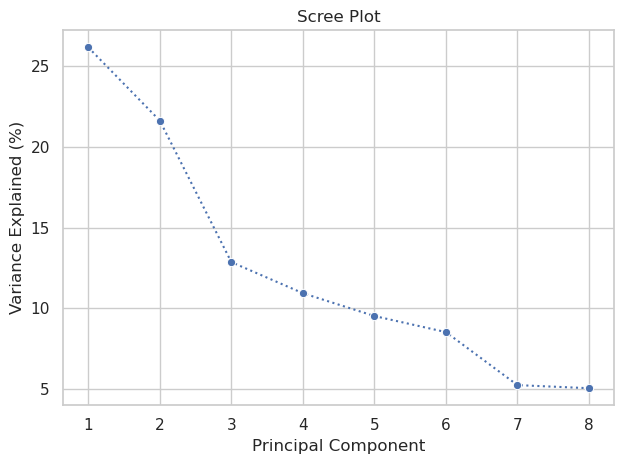

In [19]:
sns.set_theme(style='whitegrid')

sns.lineplot(
    data=pc_variances,
    x='PrComp',
    y='variance',
    linestyle='dotted',
    marker='o', sizes=20)

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')

plt.title('Scree Plot')

plt.tight_layout()
plt.show()

# Neural Netowrk - Keras
- Feature extraction
- Training/test split
- Model construction - input, 1 hidden layer, output layer
- Training and validation
- Evaluation

In [20]:
# feature extraction
x = np.array(df.drop(columns='Outcome'))

# target
y = np.array(df['Outcome'])

# training and test split (
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.3,
    random_state=42)

In [21]:
# scaler
scaler = StandardScaler().fit(x_train)

# scale train split
x_train = scaler.transform(x_train)

# scale test split
x_test = scaler.transform(x_test)

In [ ]:
#keras.backend.clear_session() # remove previous model instance

In [22]:
model = Sequential()
# input layer
model.add(Input(shape =(x_train.shape[1],)))
# hidden layer
model.add(Dense(8, activation='relu'))
# second hidden layer
#model.add(Dense(8, activation='relu'))
# output layer
model.add(Dense(1, activation='sigmoid'))

In [23]:
model.output_shape

model.get_config()

model.get_weights()

[array([[ 0.1259222 , -0.598452  ,  0.23271984,  0.037027  , -0.29767466,
         -0.4682353 , -0.29016188, -0.34561437],
        [ 0.33362943,  0.5541602 , -0.26207453,  0.34767574, -0.48281777,
          0.429861  ,  0.29812682, -0.49256653],
        [-0.46686685,  0.46170372, -0.24208552, -0.54492486,  0.5762467 ,
         -0.19736004, -0.5175588 , -0.27347544],
        [-0.5911546 , -0.4525922 , -0.37360424, -0.13066971,  0.16242927,
          0.3885172 , -0.10378933, -0.02907419],
        [ 0.03283548,  0.14842987,  0.14244163,  0.43121105,  0.37780702,
          0.28280562, -0.47262603,  0.18685073],
        [-0.21237755,  0.5439127 ,  0.10762942,  0.28499156,  0.3497303 ,
         -0.3277221 ,  0.2437517 ,  0.36520946],
        [-0.26272145,  0.34798497,  0.47608775,  0.25033092,  0.11169529,
         -0.4791847 , -0.09224474, -0.10645282],
        [ 0.25541365, -0.44302943, -0.0984422 , -0.36752868,  0.2334935 ,
          0.5171233 , -0.11862332,  0.14059162]], dtype=float32),

In [24]:
# model compilation
model.compile(loss='binary_crossentropy', # loss function for binary classification
              optimizer='adam', # adam gradient descent algorithm
              metrics=['accuracy']) # reporting metrics

model.fit(x_train, y_train,
          epochs=100,
          batch_size=10)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4749 - loss: 0.8415
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5976 - loss: 0.7346
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6457 - loss: 0.6955
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6866 - loss: 0.6330
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7160 - loss: 0.6015
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7006 - loss: 0.5784
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6991 - loss: 0.5527
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7299 - loss: 0.5280
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7302 - loss: 0.5207
Epoch 10/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7453 - loss: 0.4897
Epoch 11/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - accuracy: 0.7613 - loss: 0.4788
Epoch 12/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accurac

In [25]:
y_pred_p = model.predict(x_test) # predict y probability

y_pred = (y_pred_p > 0.5).astype(int) # assing probability a binary outcome

y_pred[:5]

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[0],
       [0],
       [0],
       [0],
       [0]])

In [26]:
score = model.evaluate(x_test, y_test, verbose=1)

print(score) # ~75%

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7450 - loss: 0.5454
[0.5501935482025146, 0.7402597665786743]


In [27]:
# confusion 
display(confusion_matrix(y_test, y_pred))

# accuracy
display(accuracy_score(y_test, y_pred))

# precision
display(precision_score(y_test, y_pred))

# recall
display(recall_score(y_test, y_pred))

# f1 score
display(f1_score(y_test, y_pred))

# cohen kappa
display(cohen_kappa_score(y_test, y_pred))

array([[121,  30],
       [ 30,  50]])

0.7402597402597403

0.625

0.625

0.625

np.float64(0.42632450331125826)

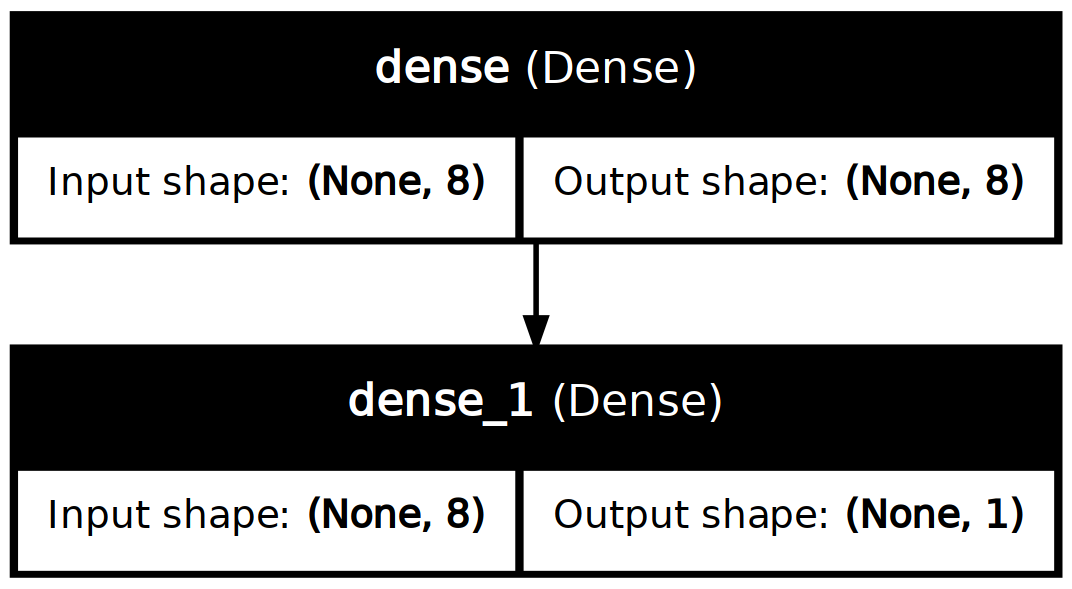

In [28]:
keras.utils.plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

# Results
In summary, the model here consists of an input layer, a single hidden layer, and an output layer, for use in binary classification of diabetes status of a sample of Pima indian women (*n* = 768) based upon 8 distinct features.

The constructed model consists of an a hidden layer which applies a ReLU function firstly, and then passes this processed data to a sigmoid activation layer to convert the data to a non-linear format in order to predict the probability of diabetes outcome (0 being non-diabetic, and 1 being diabetic).

Data were firstly separated into the target ('Outcome') and features (8 remaining variables) and then split into a training/test split at a ratio of 7:3.

The model was then trained upon this data with 100 epochs and a batch size of 10 and evaluated against the target test split. Evaluation of the model found that accuracy was c. 75% over multiple recompilations with an accuracy, precision, recall and f1 score that all approximated 62.5%.

In conclusion, this neural network model is able to predict Diabetes status on the basis of 8 physiological health features in a set of Pima indian women with an accuracy of approximately 75%.